In [ ]:
from IPython.display import clear_output

In [ ]:
# Download the required libraries (needed when running outside colab where the environment doesn't come pre-loaded with libraries)
%pip install torch
%pip install matplotlib
%pip install scikit-learn

clear_output()

In [ ]:
import torch
import torch.nn as nn
from torch.optim import SGD, Adam
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris

In [ ]:
# Load the Iris dataset
iris = load_iris()
X, y = iris.data, iris.target

In [ ]:
print(iris.DESCR)

In [ ]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert data to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

In [ ]:
# Define the neural network architecture
class NNClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(NNClassifier, self).__init__()
        self.layer1 = nn.Linear(input_size, hidden_size)
        self.layer2 = nn.Linear(hidden_size, num_classes)
        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)  # Softmax layer

    def forward(self, x):
        z1 = self.layer1(x)
        a1 = self.relu(z1)
        z2 = self.layer2(a1)
        a2 = self.softmax(z2)  # Apply softmax
        return a2

In [ ]:
input_size = 4
hidden_size = 5
num_classes = 3
learning_rate = 0.001
num_epochs = 1000
total_loss = []
# Initialize the model
model = NNClassifier(input_size, hidden_size, num_classes)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=learning_rate)

In [ ]:
# Training the model
for epoch in range(num_epochs):
    # Forward pass
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    total_loss.append(loss.item())
    # Backward and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch+1) % 100 == 0:
        print (f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [100/1000], Loss: 1.0881
Epoch [200/1000], Loss: 1.0302
Epoch [300/1000], Loss: 0.9493
Epoch [400/1000], Loss: 0.8931
Epoch [500/1000], Loss: 0.8563
Epoch [600/1000], Loss: 0.8281
Epoch [700/1000], Loss: 0.8055
Epoch [800/1000], Loss: 0.7868
Epoch [900/1000], Loss: 0.7708
Epoch [1000/1000], Loss: 0.7562


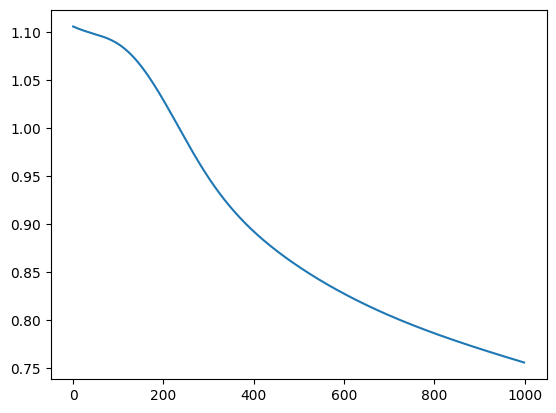

In [ ]:
plt.plot(total_loss)

In [ ]:
# Test the model
with torch.no_grad():
    outputs = model(X_test)
    _, predicted = torch.max(outputs.data, 1)
    # Accuracy
    correct = (predicted == y_test).sum().item()
    total = y_test.size(0)
    print(f'Accuracy: {(correct / total) * 100:.2f}%')

Accuracy: 93.33%


In [ ]:
# Training the model
for epoch in range(num_epochs):
    outputs = model(X)
    loss = criterion(outputs, y)
    total_loss.append(loss.item())
    loss.backward()
    optimizer.step()